## 1. Data Loading and Environment Setup

This section initialises the analytical environment and loads the processed ML ready dataset. A dynamic path detection mechanism ensures portability across different computing environments, facilitating reproducible research and collaborative workflows.

In [12]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


## 2. ARIMA Model - Univariate CPI Forecasting

ARIMA (AutoRegressive Integrated Moving Average) is a classical time series forecasting method. We'll apply it to the CPI YoY values using the same train/val/test splits as before.

In [13]:
# Prepare data for ARIMA - univariate CPI YoY
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract CPI YoY series and date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Define same splits as before
train_end = '2017-12-31'
val_end = '2021-12-31'

train_mask = df['date'] <= train_end
val_mask = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask = df['date'] > val_end

# Extract CPI YoY for ARIMA
cpi_train = df.loc[train_mask, 'cpi_yoy'].values
cpi_val = df.loc[val_mask, 'cpi_yoy'].values
cpi_test = df.loc[test_mask, 'cpi_yoy'].values

print(f"Train size: {len(cpi_train)}")
print(f"Validation size: {len(cpi_val)}")
print(f"Test size: {len(cpi_test)}")
print(f"\nTrain period: {df.loc[train_mask, 'date'].min()} to {df.loc[train_mask, 'date'].max()}")
print(f"Val period: {df.loc[val_mask, 'date'].min()} to {df.loc[val_mask, 'date'].max()}")
print(f"Test period: {df.loc[test_mask, 'date'].min()} to {df.loc[test_mask, 'date'].max()}")

Train size: 241
Validation size: 48
Test size: 38

Train period: 1997-12-01 00:00:00 to 2017-12-01 00:00:00
Val period: 2018-01-01 00:00:00 to 2021-12-01 00:00:00
Test period: 2022-01-01 00:00:00 to 2025-02-01 00:00:00


In [14]:
# Fit ARIMA model on training data
# Using ARIMA(1,1,1) as starting point - simple configuration
print("Training ARIMA(1,1,1) model...")

arima_model = ARIMA(cpi_train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print("\nModel Summary:")
print(arima_fitted.summary())

Training ARIMA(1,1,1) model...

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  241
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -28.085
Date:                Fri, 12 Dec 2025   AIC                             62.171
Time:                        18:31:25   BIC                             72.613
Sample:                             0   HQIC                            66.378
                                - 241                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5502      0.236      2.332      0.020       0.088       1.013
ma.L1         -0.4034      0.263     -1.531      0.126      -0.920       0.113
sigma

In [15]:
# Generate forecasts for validation and test sets
# Forecast step-by-step for validation
val_forecast = arima_fitted.forecast(steps=len(cpi_val))

# For test set, we need to refit on train+val
cpi_train_val = np.concatenate([cpi_train, cpi_val])
arima_model_full = ARIMA(cpi_train_val, order=(1, 1, 1))
arima_fitted_full = arima_model_full.fit()
test_forecast = arima_fitted_full.forecast(steps=len(cpi_test))

print("Validation forecast shape:", val_forecast.shape)
print("Test forecast shape:", test_forecast.shape)

Validation forecast shape: (48,)
Test forecast shape: (38,)


In [16]:
# Evaluate ARIMA performance
print("="*80)
print("ARIMA MODEL PERFORMANCE")
print("="*80)

# Validation metrics
val_mae = mean_absolute_error(cpi_val, val_forecast)
val_rmse = np.sqrt(mean_squared_error(cpi_val, val_forecast))
val_r2 = r2_score(cpi_val, val_forecast)

print(f"\nValidation Set:")
print(f"  MAE:  {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R²:   {val_r2:.4f}")

# Test metrics
test_mae = mean_absolute_error(cpi_test, test_forecast)
test_rmse = np.sqrt(mean_squared_error(cpi_test, test_forecast))
test_r2 = r2_score(cpi_test, test_forecast)

print(f"\nTest Set:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

print("="*80)

ARIMA MODEL PERFORMANCE

Validation Set:
  MAE:  1.3138
  RMSE: 1.5308
  R²:   -0.9217

Test Set:
  MAE:  2.9927
  RMSE: 3.2665
  R²:   -0.0151


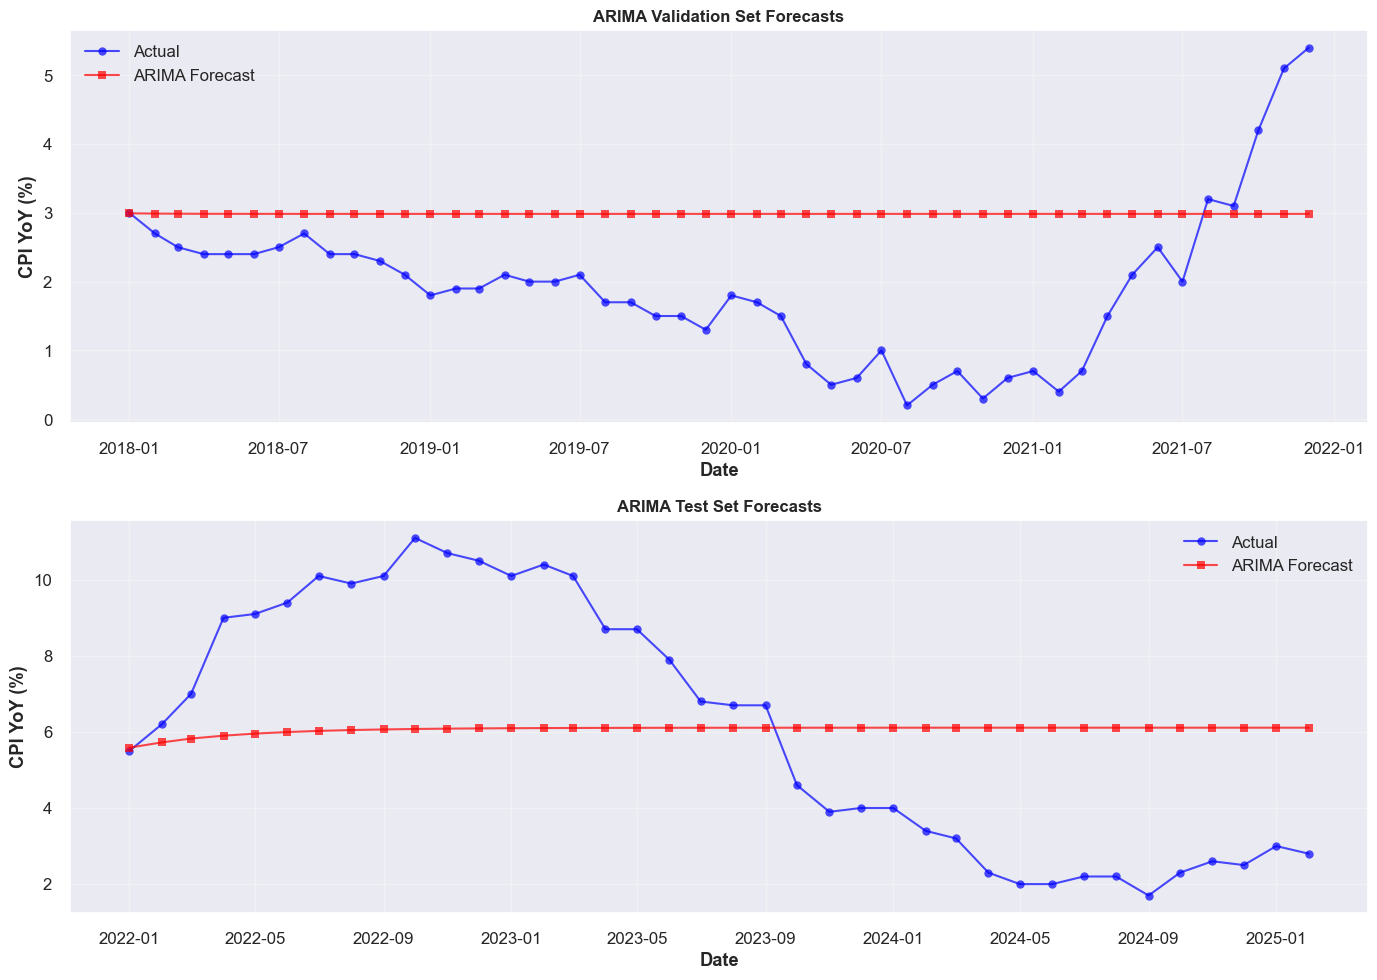

✓ Validation RMSE: 1.5308
✓ Test RMSE: 3.2665


In [17]:
# Visualize ARIMA forecasts
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Validation forecasts
ax1 = axes[0]
val_dates = df.loc[val_mask, 'date'].values
ax1.plot(val_dates, cpi_val, 'o-', label='Actual', color='blue', alpha=0.7)
ax1.plot(val_dates, val_forecast, 's-', label='ARIMA Forecast', color='red', alpha=0.7)
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('CPI YoY (%)', fontweight='bold')
ax1.set_title('ARIMA Validation Set Forecasts', fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Test forecasts
ax2 = axes[1]
test_dates = df.loc[test_mask, 'date'].values
ax2.plot(test_dates, cpi_test, 'o-', label='Actual', color='blue', alpha=0.7)
ax2.plot(test_dates, test_forecast, 's-', label='ARIMA Forecast', color='red', alpha=0.7)
ax2.set_xlabel('Date', fontweight='bold')
ax2.set_ylabel('CPI YoY (%)', fontweight='bold')
ax2.set_title('ARIMA Test Set Forecasts', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Validation RMSE: {val_rmse:.4f}")
print(f"✓ Test RMSE: {test_rmse:.4f}")